<a id="inicio-notebook"></a>
# Proyecto End to End de Machine Learning 
### Viviendas en venta en Madrid


## 0. Librerías
 

In [17]:
# importación agrupada de librerías necesarias en este notebook
import pandas as pd
import numpy as np


import sys
import os
from datetime import date

from scipy import stats
from scipy.stats import chi2_contingency
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error,make_scorer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor  # Asegúrate de tener XGBoost instalado
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, GridSearchCV

from skopt import BayesSearchCV
from skopt.space import Integer, Real

import matplotlib.pyplot as plt
import seaborn as sns

# import shap
# import lime
# from lime import lime_tabular

#warnings.filterwarnings('ignore')

# Añado el directorio padre (del que está este notebook) a sys.path
sys.path.append(os.path.abspath('../'))
from scripts.utils_agv import ini_inspec, crear_tabla_resumen, categoricas, numericas

### Configuración para visualizaciones

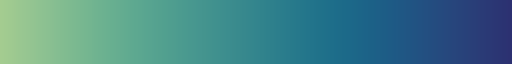

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.color_palette("crest", as_cmap=True)

<a id="baseline"></a> 
## 17. ¿Qué modelos? Baseline

(viene del notebook anterior, el conjunto de datos 'test' aquí NUNCA llegan los datos de test) He guardado los dataframe a probar en formato parquet.

Primero, importamos el parquet que queremos probar en todos nuestros modelos.

**Dataframe sin outliers, df5, con las 10 características seleccionadas con Feature Importance dentro de Random Forest, y añado 'terraza'**
En este notebook incorporo algún modelo más de boosting

In [7]:
# introduzco aquí el Dataframe en cuestión 
file = 'train_sinOutliers_df5.parquet'
file_path = f'../data/processed/{file}' 
df = pd.read_parquet(file_path, engine="pyarrow")

In [8]:
# (del notebook anterior) Listado de las mejores características correlacionadas con "price"
seleccion_RFfi = ['priceLog',
        'terraza' , 'size', 'floor', 'bathrooms', 'barrio_Lavapiés-Embajadores', 'numPhotos', 
         'hasLift', 'rooms', 'status', 'barrio_Chueca-Justicia', 'exterior'
]

# Filtrar el DataFrame con solo esas columnas
df = df[seleccion_RFfi]
df.head(10)

,priceLog,terraza,size,floor,bathrooms,barrio_Lavapiés-Embajadores,numPhotos,hasLift,rooms,status,barrio_Chueca-Justicia,exterior
ID,,,,,,,,,,,,
105764161,13.554146,0,0.693188,0.0,0.237845,0,0.879779,0,0.578130,1,0,1
105649259,13.891545,1,0.630708,2.0,0.537493,0,0.584295,1,0.578130,1,1,1
106743824,14.603968,0,0.866369,1.0,0.237845,0,0.779100,1,0.747222,1,0,1
105408030,12.560244,0,0.311003,1.0,0.000000,0,0.448665,1,0.289065,1,0,0
106463569,13.697853,0,0.603131,2.0,0.406598,0,0.517376,1,0.578130,1,0,1
107333147,14.652758,0,0.675097,2.0,0.237845,0,0.474078,1,0.578130,2,1,1
107462893,12.468437,0,0.360236,0.0,0.000000,0,0.666931,0,0.289065,0,0,1
107234286,12.706848,0,0.411136,0.0,0.000000,0,0.811525,0,0.458157,1,0,1
107021222,12.899220,0,0.562083,0.0,0.000000,1,0.598220,1,0.458157,0,0,1


In [9]:
df.shape

(1337, 12)

Primeramente hago una separación de entrenamiento y validación, para evaluar mis modelos:

In [10]:
X = df.drop(['priceLog'], axis=1)  # Eliminamos la variable objetivo
y = df['priceLog']

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42) 

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de validación: {X_val.shape}")

Tamaño del conjunto de entrenamiento: (1069, 11)
Tamaño del conjunto de validación: (268, 11)


In [12]:
# Modelo Dummy (Baseline)
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

# Predicción en la escala logarítmica
y_pred_dummy_log = dummy.predict(X_val)

# Transformar los valores a la escala original
y_val_original = np.exp(y_val)  # Revertir log(price)
y_pred_dummy_original = np.exp(y_pred_dummy_log)

# Evaluación con RMSE en la escala original
rmse_dummy = np.sqrt(mean_squared_error(y_val_original, y_pred_dummy_original))
print(f"RMSE (escala original): {rmse_dummy:,.2f} €")

# Evaluación con MAPE en la escala original
mape_dummy = mean_absolute_percentage_error(y_val_original, y_pred_dummy_original) * 100
print(f"MAPE (escala original): {mape_dummy:.2f} %")

RMSE (escala original): 584,693.47 €
MAPE (escala original): 73.68 %


### Baseline
Ahora que tenemos un modelo muy básico de referencia, realizo mi Baseline con varios modelos para regresión.

In [ ]:
# # BASELINE modelos de regresión. Complementado con AdaBoost y XGBoost
# def evaluar_modelos(X_train, X_val, y_train, y_val, grafico_error=True):
#     """
#     Evalúa múltiples modelos de regresión y devuelve métricas de error (RMSE y MAPE) en la escala original.
    
#     Parámetros:
#         - X_train, X_val: Variables predictoras para entrenamiento y validación
#         - y_train, y_val: Variables objetivo en la escala logarítmica
#         - grafico_error (bool): Si es True, muestra los gráficos de comparación

#     Retorna:
#         - resultados (dict): Diccionario con las métricas de cada modelo
#     """

#     # Definir modelos
#     modelos = {
#         'Regresión Lineal': LinearRegression(),
#         'Regresión Bayesiana': BayesianRidge(),
#         'Regresión Ridge': Ridge(),
#         'Regresión Lasso': Lasso(),
#         'Random Forest': RandomForestRegressor(random_state=42),
#         'Gradient Boosting': GradientBoostingRegressor(random_state=42),
#         'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),  # Nuevo modelo
#         'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),  # Nuevo modelo
#         'SVR Regresión': SVR(),   #support vector regressor
#         'kNN Regresión': KNeighborsRegressor(n_neighbors=5)  # Nuevo modelo KNN
#     }

#     resultados = {}

#     for nombre, modelo in modelos.items():
#         # Validación cruzada (CV) en la escala logarítmica
#         mse_cv = -cross_val_score(modelo, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
#         rmse_cv = np.sqrt(mse_cv)
        
#         # Transformar RMSE CV a escala original (aproximación)
#         rmse_cv_original = np.exp(rmse_cv)

#         # Entrenamiento del modelo
#         modelo.fit(X_train, y_train)

#         # Predicciones en la escala logarítmica
#         y_pred_log = modelo.predict(X_val)

#         # Transformar a la escala original
#         y_val_original = np.exp(y_val)
#         y_pred_original = np.exp(y_pred_log)

#         # Evaluación en la escala original
#         rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
#         mape = mean_absolute_percentage_error(y_val_original, y_pred_original) * 100

#         # Guardar resultados
#         resultados[nombre] = {
#             'RMSE CV': rmse_cv_original.mean(),
#             'RMSE Val': rmse,
#             'MAPE Val': mape,
#             'Modelo': modelo
#         }

#         # Imprimir métricas
#         print(f"\nModelo: {nombre}")
#         print(f"RMSE CV (original): {rmse_cv_original.mean():,.2f} €")
#         print(f"RMSE val (original): {rmse:,.2f} €")
#         print(f"MAPE val (original): {mape:.2f} %")

#     # Si grafico_error es True, mostramos las comparaciones gráficas
#     if grafico_error:
#         nombres_modelos = list(resultados.keys())
#         rmse_valores = [resultados[m]['RMSE Val'] for m in nombres_modelos]
#         mape_valores = [resultados[m]['MAPE Val'] for m in nombres_modelos]

#         plt.figure(figsize=(14, 6))

#         # Gráfico RMSE
#         plt.subplot(1, 2, 1)
#         sns.barplot(x=nombres_modelos, y=rmse_valores)
#         plt.title('Comparación de RMSE por Modelo')
#         plt.xticks(rotation=45)
#         plt.ylabel('RMSE (Escala Original,€)')

#         # Gráfico MAPE
#         plt.subplot(1, 2, 2)
#         sns.barplot(x=nombres_modelos, y=mape_valores)
#         plt.title('Comparación de MAPE por Modelo')
#         plt.xticks(rotation=45)
#         plt.ylabel('MAPE (%)')

#         plt.tight_layout()
#         plt.show()

#     return resultados

# # Uso de la función
# resultados_modelos = evaluar_modelos(X_train, X_val, y_train, y_val, grafico_error=True)



Modelo: Regresión Lineal
RMSE CV (original): 272,391.46 €
RMSE val (original): 222,234.56 €
MAPE val (original): 18.70 %

Modelo: Regresión Bayesiana
RMSE CV (original): 272,841.03 €
RMSE val (original): 222,014.46 €
MAPE val (original): 18.70 %

Modelo: Regresión Ridge
RMSE CV (original): 279,041.56 €
RMSE val (original): 222,625.25 €
MAPE val (original): 18.88 %

Modelo: Regresión Lasso
RMSE CV (original): 606,096.78 €
RMSE val (original): 584,693.47 €
MAPE val (original): 73.68 %

Modelo: Random Forest
RMSE CV (original): 244,589.14 €
RMSE val (original): 251,869.06 €
MAPE val (original): 16.83 %

Modelo: Gradient Boosting
RMSE CV (original): 238,912.42 €
RMSE val (original): 213,304.29 €
MAPE val (original): 17.17 %

Modelo: AdaBoost
RMSE CV (original): 296,677.90 €
RMSE val (original): 292,789.66 €
MAPE val (original): 21.96 %

Modelo: XGBoost
RMSE CV (original): 244,612.88 €
RMSE val (original): 215,842.82 €
MAPE val (original): 17.40 %

Modelo: SVR Regresión
RMSE CV (original):

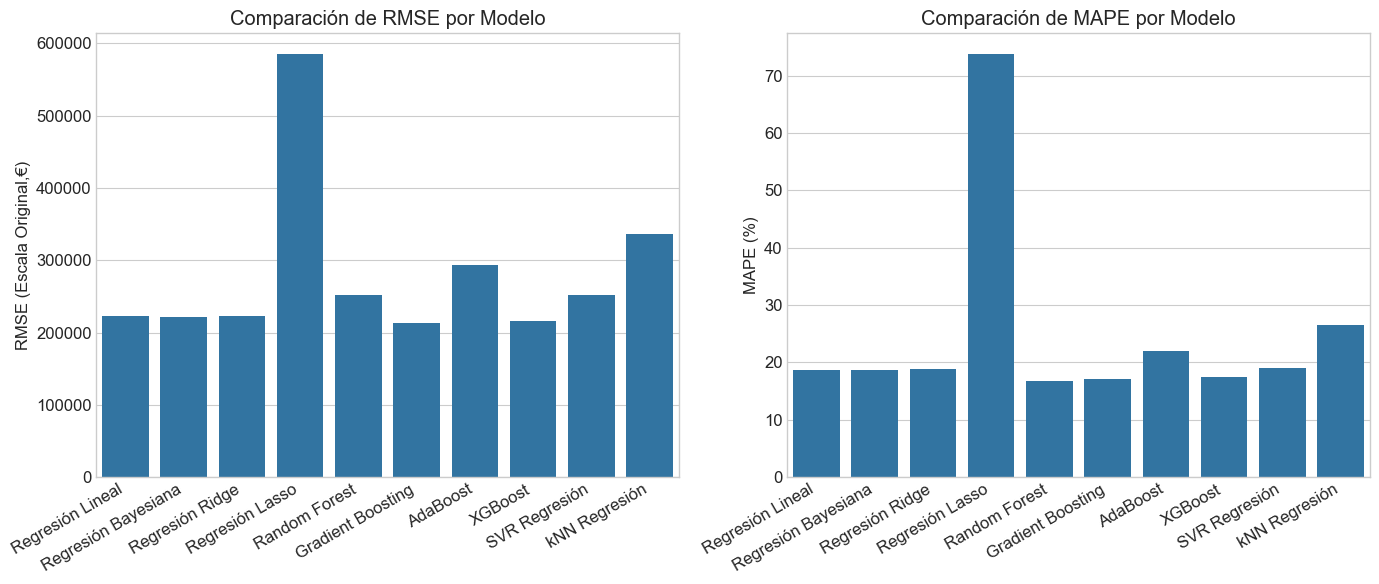

In [27]:
# BASELINE v2, mejorado CV modelos de regresión. Complementado con AdaBoost y XGBoost
def evaluar_modelos(X_train, X_val, y_train, y_val, grafico_error=True):
    """
    Evalúa múltiples modelos de regresión y devuelve métricas de error (RMSE y MAPE) en la escala original.
    
    Parámetros:
        - X_train, X_val: Variables predictoras para entrenamiento y validación
        - y_train, y_val: Variables objetivo en la escala logarítmica
        - grafico_error (bool): Si es True, muestra los gráficos de comparación

    Retorna:
        - resultados (dict): Diccionario con las métricas de cada modelo
    """

    # Definir modelos
    modelos = {
        'Regresión Lineal': LinearRegression(),
        'Regresión Bayesiana': BayesianRidge(),
        'Regresión Ridge': Ridge(),
        'Regresión Lasso': Lasso(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),  # Nuevo modelo
        'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),  # Nuevo modelo
        'SVR Regresión': SVR(),   #support vector regressor
        'kNN Regresión': KNeighborsRegressor(n_neighbors=5)  # Nuevo modelo KNN
    }

    resultados = {}
    
    # Definir función para calcular RMSE en escala original
    def rmse_original(y_true, y_pred):
        y_true_original = np.exp(y_true)
        y_pred_original = np.exp(y_pred)
        return -np.sqrt(mean_squared_error(y_true_original, y_pred_original))

    for nombre, modelo in modelos.items():
        # Validación cruzada (CV) en la escala logarítmica
        mse_cv = -cross_val_score(modelo, X_train, y_train, cv=5, 
                                  scoring='neg_mean_squared_error')
        
        # Transformar RMSE CV a escala original (usando función)
        rmse_cv_original = -cross_val_score(modelo, X_train, y_train, cv=5, 
                                   scoring=make_scorer(rmse_original))

        # Entrenamiento del modelo
        modelo.fit(X_train, y_train)

        # Predicciones en la escala logarítmica
        y_pred_log = modelo.predict(X_val)

        # Transformar a la escala original
        y_val_original = np.exp(y_val)
        y_pred_original = np.exp(y_pred_log)

        # Evaluación en la escala original
        rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
        mape = mean_absolute_percentage_error(y_val_original, y_pred_original) * 100

        # Guardar resultados
        resultados[nombre] = {
            'RMSE CV': rmse_cv_original.mean(),
            'RMSE Val': rmse,
            'MAPE Val': mape,
            'Modelo': modelo
        }

        # Imprimir métricas
        print(f"\nModelo: {nombre}")
        print(f"RMSE CV (original): {rmse_cv_original.mean():,.2f} €")
        print(f"RMSE val (original): {rmse:,.2f} €")
        print(f"MAPE val (original): {mape:.2f} %")

    # Si grafico_error es True, mostramos las comparaciones gráficas
    if grafico_error:
        nombres_modelos = list(resultados.keys())
        rmse_valores = [resultados[m]['RMSE Val'] for m in nombres_modelos]
        mape_valores = [resultados[m]['MAPE Val'] for m in nombres_modelos]

        plt.figure(figsize=(14, 6))

        # Gráfico RMSE
        plt.subplot(1, 2, 1)
        sns.barplot(x=nombres_modelos, y=rmse_valores)
        plt.title('Comparación de RMSE por Modelo')
        plt.xticks(ticks=range(len(nombres_modelos)), labels=nombres_modelos, rotation=30, ha='right')  # Alineado a la derecha
        plt.ylabel('RMSE (Escala Original,€)')

        # Gráfico MAPE
        plt.subplot(1, 2, 2)
        sns.barplot(x=nombres_modelos, y=mape_valores)
        plt.title('Comparación de MAPE por Modelo')
        plt.xticks(ticks=range(len(nombres_modelos)), labels=nombres_modelos, rotation=30, ha='right')  # Alineado a la derecha
        plt.ylabel('MAPE (%)')

        plt.tight_layout()
        plt.show()

    return resultados

# Uso de la función
resultados_modelos = evaluar_modelos(X_train, X_val, y_train, y_val, grafico_error=True)


In [28]:
resultados_modelos

{'Regresión Lineal': {'RMSE CV': np.float64(272391.45974501857),
  'RMSE Val': np.float64(222234.5635415938),
  'MAPE Val': 18.69946016541986,
  'Modelo': LinearRegression()},
 'Regresión Bayesiana': {'RMSE CV': np.float64(272841.03420999553),
  'RMSE Val': np.float64(222014.46239446814),
  'MAPE Val': 18.702609666327774,
  'Modelo': BayesianRidge()},
 'Regresión Ridge': {'RMSE CV': np.float64(279041.5618463124),
  'RMSE Val': np.float64(222625.25060637866),
  'MAPE Val': 18.882214628348247,
  'Modelo': Ridge()},
 'Regresión Lasso': {'RMSE CV': np.float64(606096.7816664114),
  'RMSE Val': np.float64(584693.4675053775),
  'MAPE Val': 73.68081017481886,
  'Modelo': Lasso()},
 'Random Forest': {'RMSE CV': np.float64(244589.14063657093),
  'RMSE Val': np.float64(251869.05679978122),
  'MAPE Val': 16.82730429196361,
  'Modelo': RandomForestRegressor(random_state=42)},
 'Gradient Boosting': {'RMSE CV': np.float64(238912.42479468556),
  'RMSE Val': np.float64(213304.2867252931),
  'MAPE Val':

_Reduciendo nuestros datos a las 10 columnas seleccionadas por Feature Importance de Random Forest, los modelos mejoran muy, muy poco, apenas perceptible.  El mejor modelo, de momento, es Gradient Boosting, seguido por XGBoost, según el error RMSE. Aunque Random Forest tiene menor error medio porcentual (MAPE). También están proximos Regresión Bayesiana, o Regresión Ridge, ambos más sencillos y eficientes._

<a id="hyperparmeters"></a>
<a href="#inicio-notebook"><p style="text-align:right;" href="#inicio-notebook">Volver al inicio</p></a> 
## 18. Elegir hiperparámetros

Con varios de los modelos que han resultado mejores, pero que andan varios muy próximos, voy a ajustar hiperparámetros, a ver cual combinación es la mejor para mis datos.

In [30]:
# listado de parámetros explicados
# REGRESIÓN LINEAL
grid_linear = {
    "fit_intercept": [True, False],  # Incluir o no el término independiente (bias)
    "positive": [True, False]  # Forzar coeficientes positivos
}


# REGRESIÓN RIDGE
grid_ridge = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0],  # Controla la regularización (mayor α = más regularización)
    "fit_intercept": [True, False],  # Incluir o no el término independiente
    "solver": ["auto", "svd", "cholesky", "lsqr", "saga"],  # Diferentes métodos de optimización
    "max_iter": [100, 500, 1000]  # Iteraciones (solo afecta en algunos solvers)
}


# RANDOM FOREST
grid_random_forest = {"n_estimators": [120], # El Random Forest no suele empeorar por exceso de
                                             # estimadores. A partir de cierto numero no merece la pena
                                             # perder el tiempo ya que no mejora mucho más la precisión.
                                             # Entre 100 y 200 es una buena cifra

                     
                     "max_depth": [3,4,5,6,10,15,17], # No le afecta tanto el overfitting como al decissiontree.
                                                      # Podemos probar mayores profundidades
                      
                     "max_features": ["sqrt", 3, 4] # Numero de features que utiliza en cada split.
                                                    # cuanto más bajo, mejor generalizará y menos overfitting.
                                                    
                     }


# GRADIENT BOOSTING
grid_gradient_boosting = {"loss": ["deviance"], # Deviance suele ir mejor.
                          "learning_rate": [0.05, 0.1, 0.2, 0.4, 0.5],  # Cuanto más alto, mas aporta cada nuevo arbol
                          
                          "n_estimators": [20,50,100,200], # Cuidado con poner muchos estiamdores ya que vamos a
                                                           # sobreajustar el modelo
                          
                          "max_depth": [1,2,3,4,5], # No es necesario poner una profundiad muy alta. Cada nuevo
                                                    # arbol va corrigiendo el error de los anteriores.
                          
                          
                          "max_features": ["sqrt", 3, 4], # Igual que en el random forest
                          }

# ADA BOOST
grid_adaboost = {
    "n_estimators": [50, 100, 200, 300],  # Número de árboles (suele funcionar bien en 50-200)
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],  # Tasa de aprendizaje, más alta puede acelerar pero sobreajustar
    "loss": ["linear", "square", "exponential"]  # Función de pérdida (para AdaBoostRegressor)
}

# XGBOOST
grid_xgboost = {
    "n_estimators": [50, 100, 200, 500],  # Número de árboles en el ensamble
    "learning_rate": [0.01, 0.05, 0.1, 0.2],  # Tasa de aprendizaje (más baja evita sobreajuste)
    "max_depth": [3, 5, 7, 10],  # Profundidad máxima de los árboles
    "subsample": [0.6, 0.8, 1.0],  # Porcentaje de datos usados en cada árbol (menos puede mejorar la generalización)
    "colsample_bytree": [0.6, 0.8, 1.0],  # Fracción de features usadas en cada árbol
    "gamma": [0, 0.1, 0.3, 0.5],  # Poda de árboles (mayores valores = más regularización)
    "reg_alpha": [0, 0.1, 1, 10],  # Regularización L1 (sparse features)
    "reg_lambda": [0, 0.1, 1, 10]  # Regularización L2 (ridge penalty)
}

In [31]:
# (1/5) Optimización Grid para Regresión Lineal. Errores en escala original
print("\nRealizando Optimización Grid para Regresión Lineal...")

# Definir el espacio de hiperparámetros para la regresión lineal
grid_linear = {
    "fit_intercept": [True, False],  # Incluir o no el término independiente
    "positive": [True, False]  # Forzar coeficientes positivos
}

# Crear el modelo base de regresión lineal
modelo_linear = LinearRegression()

# Configurar GridSearchCV con validación cruzada de 5 folds
grid_search_linear = GridSearchCV(
    modelo_linear,
    grid_linear,
    cv=5,
    scoring="neg_mean_squared_error",  # Se usa MSE negativo para minimizarlo
    n_jobs=-1
)

# Entrenar el modelo
grid_search_linear.fit(X_train, y_train)

# Obtener el mejor modelo encontrado
mejor_lineal = grid_search_linear.best_estimator_

# Predicciones en la escala logarítmica
y_pred_log = mejor_lineal.predict(X_val)

# Transformar a la escala original (de log a original)
y_val_original = np.exp(y_val)
y_pred_original = np.exp(y_pred_log)

# Evaluación en la escala original
rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
mape = mean_absolute_percentage_error(y_val_original, y_pred_original) * 100

# Imprimir resultados
print(f"\nMejores parámetros: {grid_search_linear.best_params_}")
print(f"Mejor RMSE CV: {-grid_search_linear.best_score_:.2f}")  # Se niega MSE para convertirlo en positivo
print(f"RMSE val (original): {rmse:,.2f} €")
print(f"MAPE val (original): {mape:.2f} %")

# Mostramos el mejor modelo de Regresión Lineal
mejor_lineal



Realizando Optimización Grid para Regresión Lineal...



Mejores parámetros: {'fit_intercept': True, 'positive': False}
Mejor RMSE CV: 0.06
RMSE val (original): 222,234.56 €
MAPE val (original): 18.70 %


LinearRegression()

In [32]:
# (2/5) Optimización Grid para Ridge. Errores en escala original
print("\nRealizando Optimización Grid para Regresión lineal Ridge...")

# Definir el espacio de hiperparámetros para Ridge
grid_ridge = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0],  # Controla la regularización
    "fit_intercept": [True, False],  # Incluir o no el término independiente
    "solver": ["auto", "svd", "cholesky", "lsqr", "saga"],  # Métodos de optimización
    "max_iter": [1000, 2000]  # Número de iteraciones
}

# Crear el modelo base Ridge
modelo_ridge = Ridge()

# Configurar GridSearchCV con validación cruzada de 5 folds
grid_search_ridge = GridSearchCV(
    modelo_ridge, 
    grid_ridge, 
    cv=5, 
    scoring="neg_mean_squared_error",  # Se usa MSE negativo para minimizarlo
    n_jobs=-1
)

# Entrenar el modelo
grid_search_ridge.fit(X_train, y_train)

# Obtener el mejor modelo encontrado
mejor_ridge = grid_search_ridge.best_estimator_

# Predicciones en la escala logarítmica
y_pred_log = mejor_ridge.predict(X_val)

# Transformar a la escala original
y_val_original = np.exp(y_val)
y_pred_original = np.exp(y_pred_log)

# Evaluación en la escala original
rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
mape = mean_absolute_percentage_error(y_val_original, y_pred_original) * 100

# Imprimir resultados
print(f"\nMejores parámetros: {grid_search_ridge.best_params_}")
print(f"Mejor RMSE CV: {-grid_search_ridge.best_score_:.2f}")  # Se niega MSE para convertirlo en positivo
print(f"RMSE val (original): {rmse:,.2f} €")
print(f"MAPE val (original): {mape:.2f} %")

# Mostramos el mejor modelo Ridge
mejor_ridge



Realizando Optimización Grid para Regresión lineal Ridge...



Mejores parámetros: {'alpha': 0.01, 'fit_intercept': True, 'max_iter': 1000, 'solver': 'auto'}
Mejor RMSE CV: 0.06
RMSE val (original): 222,201.59 €
MAPE val (original): 18.70 %


Ridge(alpha=0.01, max_iter=1000)

In [33]:
# (3/5) Optimización Bayesiana para Gradient Boosting. Errores en escala original
print("\nRealizando Optimización Bayesiana para Gradient Boosting...")

# Espacio de búsqueda de hiperparámetros
param_space = {
    'n_estimators': Integer(50, 300),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'subsample': Real(0.6, 1.0)
}

# Optimización Bayesiana con validación cruzada
bayes_search = BayesSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_space,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',  # Usamos MSE para minimizarlo
    n_jobs=-1,
    random_state=42
)

# Entrenar el modelo
bayes_search.fit(X_train, y_train)

# Obtener el mejor modelo
mejor_gb = bayes_search.best_estimator_

# Predicciones en la escala logarítmica
y_pred_log = mejor_gb.predict(X_val)

# Transformar a la escala original
y_val_original = np.exp(y_val)
y_pred_original = np.exp(y_pred_log)

# Evaluación en la escala original
rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
mape = mean_absolute_percentage_error(y_val_original, y_pred_original) * 100

# Imprimir resultados
print(f"\nMejores parámetros: {bayes_search.best_params_}")
print(f"Mejor RMSE CV: {-bayes_search.best_score_:.2f}")  # Negamos MSE para hacerlo positivo y en escala original
print(f"RMSE val (original): {rmse:,.2f} €")
print(f"MAPE val (original): {mape:.2f} %")

# Guardamos el mejor modelo Gradient Boosting
mejor_gb



Realizando Optimización Bayesiana para Gradient Boosting...



Mejores parámetros: OrderedDict([('learning_rate', 0.024166621741563987), ('max_depth', 6), ('min_samples_leaf', 7), ('min_samples_split', 17), ('n_estimators', 257), ('subsample', 0.6008945150939967)])
Mejor RMSE CV: 0.05
RMSE val (original): 222,664.36 €
MAPE val (original): 16.92 %


GradientBoostingRegressor(learning_rate=0.024166621741563987, max_depth=6,
                          min_samples_leaf=7, min_samples_split=17,
                          n_estimators=257, random_state=42,
                          subsample=0.6008945150939967)

In [34]:
# /4/5) Optimización Grid para RF. Errores en escala original
print("\nRealizando Grid Search para Random Forest...")

# Definir el espacio de hiperparámetros para el Random Forest
param_grid = {
    'n_estimators': [50, 100, 200, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Configurar GridSearchCV con validación cruzada de 5 folds
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                            cv=5, scoring='neg_mean_squared_error',  # Usamos MSE para minimizarlo
                            n_jobs=-1)
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo
mejor_rf = grid_search.best_estimator_

# Predicciones en la escala logarítmica
y_pred_log = mejor_rf.predict(X_val)

# Transformar a la escala original (de log a original)
y_val_original = np.exp(y_val)
y_pred_original = np.exp(y_pred_log)

# Evaluación en la escala original
rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
mape = mean_absolute_percentage_error(y_val_original, y_pred_original) * 100

# Imprimir resultados
print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor RMSE CV: {grid_search.best_score_:.4f}")
print(f"RMSE val (original): {rmse:,.2f} €")
print(f"MAPE val (original): {mape:.2f} %")

# Mostramos el mejor modelo Random Forest
mejor_rf



Realizando Grid Search para Random Forest...

Mejores parámetros: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Mejor RMSE CV: -0.0560
RMSE val (original): 249,064.55 €
MAPE val (original): 16.67 %


RandomForestRegressor(max_depth=20, n_estimators=400, random_state=42)

In [45]:
# # (5/5) Optimización Grid para XGBoost. Errores en escala original
# print("\nRealizando Grid Search para XGBoost...")

# # Definir el espacio de hiperparámetros para XGBoost
# param_grid_xgb = {
#     'n_estimators': [50, 100, 200, 500],  # Número de árboles
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Tasa de aprendizaje
#     'max_depth': [3, 5, 7, 10],  # Profundidad máxima de los árboles
#     'subsample': [0.6, 0.8, 1.0],  # Fracción de datos usada en cada árbol
#     'colsample_bytree': [0.6, 0.8, 1.0],  # Fracción de features usadas en cada árbol
#     'gamma': [0, 0.1, 0.3, 0.5],  # Regularización mediante poda
#     'reg_alpha': [0, 0.1, 1, 10],  # Regularización L1
#     'reg_lambda': [0, 0.1, 1, 10]  # Regularización L2
# }

# # Configurar GridSearchCV con validación cruzada de 5 folds
# grid_search_xgb = GridSearchCV(
#     XGBRegressor(objective='reg:squarederror', random_state=42),  # Especificar el objetivo de regresión
#     param_grid_xgb,
#     cv=5,  # Validación cruzada de 5 folds
#     scoring='neg_mean_squared_error',  # Minimizar el MSE
#     n_jobs=-1  # Usar todos los núcleos disponibles
# )

# # Entrenar el GridSearch
# grid_search_xgb.fit(X_train, y_train)

# # Obtener el mejor modelo
# mejor_xgb0 = grid_search_xgb.best_estimator_

# # Predicciones en la escala logarítmica
# y_pred_log = mejor_xgb0.predict(X_val)

# # Transformar a la escala original (de log a original)
# y_val_original = np.exp(y_val)
# y_pred_original = np.exp(y_pred_log)

# # Evaluación en la escala original
# rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
# mape = mean_absolute_percentage_error(y_val_original, y_pred_original) * 100

# # Imprimir resultados finales
# print(f"\nMejores parámetros: {grid_search_xgb.best_params_}")
# print(f"Mejor RMSE CV: {np.sqrt(-grid_search_xgb.best_score_):,.4f}")
# print(f"RMSE val (original): {rmse:,.2f} €")
# print(f"MAPE val (original): {mape:.2f} %")

# # Mostramos el mejor modelo XGBoost, de todos los parametros, reservamos:
# dado que tarda unos 160-180 minutos, lo reservo como mejor_xgb0 para no tener que volver a ejecutar esta celda.
# mejor_xgb0



Realizando Grid Search para XGBoost...
Mejores parámetros: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.6}
Mejor RMSE CV: 0.2229

Mejores parámetros: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.6}
Mejor RMSE CV: 0.2229
RMSE val (original): 230,419.54 €
MAPE val (original): 17.43 %


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [50]:
# (5/5) OPC2 menos hiperparámetros: Optimización Grid para XGBoost. Errores en escala original
print("\nRealizando Grid Search para XGBoost...")

# Definir el espacio de hiperparámetros para XGBoost
param_grid_xgb = {
    'n_estimators': [50, 200],  # Número de árboles
    'learning_rate': [0.01, 0.1],  # Tasa de aprendizaje
    'max_depth': [3, 7],  # Profundidad máxima de los árboles
    'subsample': [ 0.8, 1.0],  # Fracción de datos usada en cada árbol
    'colsample_bytree': [ 0.8, 1.0],  # Fracción de features usadas en cada árbol
    'gamma': [0, 0.3],  # Regularización mediante poda
    'reg_alpha': [0, 1],  # Regularización L1
    'reg_lambda': [0.1, 1]  # Regularización L2
}

# Configurar GridSearchCV con validación cruzada de 5 folds
grid_search_xgb = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42),  # Especificar el objetivo de regresión
    param_grid_xgb,
    cv=5,  # Validación cruzada de 5 folds
    scoring='neg_mean_squared_error',  # Minimizar el MSE
    n_jobs=-1  # Usar todos los núcleos disponibles
)

# Entrenar el GridSearch
grid_search_xgb.fit(X_train, y_train)

# Obtener el mejor modelo
mejor_xgb = grid_search_xgb.best_estimator_

# Predicciones en la escala logarítmica
y_pred_log = mejor_xgb.predict(X_val)

# Transformar a la escala original (de log a original)
y_val_original = np.exp(y_val)
y_pred_original = np.exp(y_pred_log)

# Evaluación en la escala original
rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
mape = mean_absolute_percentage_error(y_val_original, y_pred_original) * 100

# Imprimir resultados finales
print(f"\nMejores parámetros: {grid_search_xgb.best_params_}")
print(f"Mejor RMSE CV: {np.sqrt(-grid_search_xgb.best_score_):,.4f}")
print(f"RMSE val (original): {rmse:,.2f} €")
print(f"MAPE val (original): {mape:.2f} %")

# Mostramos el mejor modelo XGBoost
mejor_xgb



Realizando Grid Search para XGBoost...

Mejores parámetros: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 0.1, 'subsample': 0.8}
Mejor RMSE CV: 0.2291
RMSE val (original): 224,697.82 €
MAPE val (original): 17.34 %


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

He incorporardo XGBoost como un muy buen modelo. Después de probar los mejores hiperparámetros en los cinco modelos que he seleccionado como "mejores", estos no mejoran demasiado mi modelo, ni definen claramente un ganador diferente que destaque. 

Así pues, por sencillez y eficiencia (rapidez y coste computacional), me quedo con la **Regresión Lineal Ridge, o de cresta o regresión L2 regularizada**. 
Este modelo incluye un termino de penalización que evita que los coeficientes se ajusten demasiado en el entrenamiento, y penaliza los valores grandes de estos coeficientes, forzándoles a ser pequeños, compensando así.

Realizo un cuadro resumen de los modelos probados, señalando los que son los mejores según los resultados

In [ ]:
#probando
rmse_cv_regresion_lineal = resultados_modelos['Regresión Lineal']['RMSE CV']
print(f"{rmse_cv_regresion_lineal:,.2f} %")

In [ ]:
# probando
f"{resultados_modelos['Regresión Lineal']['RMSE CV']:,.2f} €"

In [108]:
# Crear lista de modelos con Dummy al inicio
def rmse_original(y_true, y_pred):
    y_true_original = np.exp(y_true)
    y_pred_original = np.exp(y_pred)
    return -np.sqrt(mean_squared_error(y_true_original, y_pred_original))

nombres_modelos = ["Dummy Regressor"] + list(resultados_modelos.keys())

# Lista con las métricas del Dummy Regressor (debes definir estos valores antes)
errores_dummy = [None, f"{rmse_dummy:,.2f} €", f"{mape_dummy:.2f} %"]  # Ajusta las variables correctas

# Extraer métricas de la evaluación inicial
errores_iniciales = [errores_dummy] + [
    [f"{resultados_modelos[m]['RMSE CV']:,.2f} €",
    f"{resultados_modelos[m]['RMSE Val']:,.2f} €",
    f"{resultados_modelos[m]['MAPE Val']:,.2f} %"]
    for m in resultados_modelos.keys()]


# Diccionario con los modelos optimizados
modelos_optimizados = {
    'Regresión Lineal': mejor_lineal if 'mejor_lineal' in locals() else None,
    'Regresión Bayesiana': mejor_bayes if 'mejor_bayes' in locals() else None,
    'Regresión Ridge': mejor_ridge if 'mejor_ridge' in locals() else None,
    'Regresión Lasso': mejor_lasso if 'mejor_lasso' in locals() else None,
    'Random Forest': mejor_rf if 'mejor_rf' in locals() else None,
    'Gradient Boosting': mejor_gb if 'mejor_gb' in locals() else None,
    'AdaBoost': mejor_ada if 'mejor_ada' in locals() else None,
    'XGBoost': mejor_xgb if 'mejor_xgb' in locals() else None,
    'SVR Regresión': mejor_svr if 'mejor_svr' in locals() else None,
    'kNN Regresión': mejor_knn if 'mejor_knn' in locals() else None
}

# Extraer métricas de los modelos optimizados (si existen, sino dejar vacío)
errores_optimizados = []
for nombre in nombres_modelos:
    modelo_opt = modelos_optimizados.get(nombre)  # Obtener modelo optimizado si existe
    if modelo_opt:
        y_pred_opt = modelo_opt.predict(X_val)
        y_pred_opt_original = np.exp(y_pred_opt)  # Transformar de log a escala original

        # Calcular métricas
        rmse_opt = np.sqrt(mean_squared_error(y_val_original, y_pred_opt_original))
        mape_opt = mean_absolute_percentage_error(y_val_original, y_pred_opt_original) * 100
        rmse_cv_original = -cross_val_score(modelo_opt, X_train, y_train, cv=5, scoring=make_scorer(rmse_original))
        errores_optimizados.append([f"{rmse_cv_original.mean():,.2f} €", f"{rmse_opt:,.2f} €", f"{mape_opt:,.2f} %"])  # RMSE CV no aplica
    else:
        errores_optimizados.append([None, None, None])  # Si no hay modelo optimizado, dejar vacío

# Crear DataFrame
df_resumen = pd.DataFrame(
    data=np.column_stack((nombres_modelos, errores_iniciales, errores_optimizados)),
    columns=["Modelo", "RMSE CV Inicial", "RMSE Val Inicial", "MAPE Val Inicial",
             "RMSE CV Optimizado", "RMSE Val Optimizado", "MAPE Val Optimizado"]
)

# Convertir valores numéricos
#df_resumen.iloc[:, 1:] = df_resumen.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# Mostrar el DataFrame
df_resumen

# También puedes guardar el resumen en CSV o Excel
df_resumen.to_csv("resumen_modelos.csv", index=False)
# df_resumen.to_excel("resumen_modelos.xlsx", index=False)


### Comprobación del sobreajuste de los modelos

In [38]:
# Función verificar_sobreajuste (modelo)
def verificar_sobreajuste(modelo, X_train, X_val, y_train, y_val):
    """
    Verifica si el modelo está sobreajustado comparando las métricas de entrenamiento y validación.
    
    Parámetros:
        - modelo: El modelo entrenado.
        - X_train, X_val: Variables predictoras para entrenamiento y validación.
        - y_train, y_val: Variables objetivo para entrenamiento y validación.
        
    Retorna:
        - None, pero imprime las métricas.
    """
    # Predicciones en el conjunto de entrenamiento y validación
    y_train_pred = modelo.predict(X_train)
    y_val_pred = modelo.predict(X_val)

    # Transformar a la escala original
    y_train_original = np.exp(y_train)
    y_val_original = np.exp(y_val)
    
    y_train_pred_original = np.exp(y_train_pred)
    y_val_pred_original = np.exp(y_val_pred)

    # Calcular métricas RMSE y MAPE
    rmse_train = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
    rmse_val = np.sqrt(mean_squared_error(y_val_original, y_val_pred_original))
    mape_train = mean_absolute_percentage_error(y_train_original, y_train_pred_original) * 100
    mape_val = mean_absolute_percentage_error(y_val_original, y_val_pred_original) * 100

    print(f"Modelo: {modelo.__class__.__name__}")
    print(f"RMSE entrenamiento (original): {rmse_train:,.2f} €")
    print(f"RMSE validación (original): {rmse_val:,.2f} €")
    print(f"MAPE entrenamiento (original): {mape_train:.2f} %")
    print(f"MAPE validación (original): {mape_val:.2f} %")

    # Verificar si el modelo está sobreajustado
    if rmse_train < rmse_val and mape_train < mape_val:
        print("El modelo podría estar sobreajustado (overfitting).")
    else:
        print("El modelo parece estar bien ajustado.")


In [39]:
# Comprobación de uso con mis modelos con hiperparámetros
# modelo_ridge = Ridge(alpha=0.01, fit_intercept=True, max_iter=1000, solver='lsqr')
# modelo_ridge.fit(X_train, y_train)
verificar_sobreajuste(mejor_lineal, X_train, X_val, y_train, y_val)
verificar_sobreajuste(mejor_ridge, X_train, X_val, y_train, y_val)

Modelo: LinearRegression
RMSE entrenamiento (original): 267,508.31 €
RMSE validación (original): 222,234.56 €
MAPE entrenamiento (original): 19.05 %
MAPE validación (original): 18.70 %
El modelo parece estar bien ajustado.
Modelo: Ridge
RMSE entrenamiento (original): 267,560.84 €
RMSE validación (original): 222,201.59 €
MAPE entrenamiento (original): 19.05 %
MAPE validación (original): 18.70 %
El modelo parece estar bien ajustado.


In [40]:
def graficar_aprendizaje(modelo, X_train, y_train, X_val, y_val):
    """
    Genera un gráfico de aprendizaje para el modelo, mostrando el error de entrenamiento y validación.
    """
    train_errors, val_errors = [], []
    
    # Ajustar el modelo mientras calculamos los errores de entrenamiento y validación
    for i in range(1, 201):
        modelo.n_estimators = i
        modelo.fit(X_train, y_train)
        
        y_train_pred = modelo.predict(X_train)
        y_val_pred = modelo.predict(X_val)
        
        train_errors.append(mean_squared_error(y_train, y_train_pred))
        val_errors.append(mean_squared_error(y_val, y_val_pred))

    # Graficar
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, 201), train_errors, label="Error de entrenamiento", color='blue')
    plt.plot(range(1, 201), val_errors, label="Error de validación", color='red')
    plt.title('Gráfico de Aprendizaje')
    plt.xlabel('Número de estimadores (iteraciones)')
    plt.ylabel('Error (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()



In [41]:

def graficar_aprendizaje(modelo, X_train, y_train, X_val, y_val):
    """
    Genera un gráfico de aprendizaje para el modelo, mostrando el error de entrenamiento y validación.
    Además, indica el punto donde el error de entrenamiento es igual al de validación y dibuja una línea vertical.
    Imprime el número de iteraciones a partir de las cuales las 10 siguientes no mejoran.
    """
    train_errors, val_errors = [], []
    
    # Ajustar el modelo mientras calculamos los errores de entrenamiento y validación
    for i in range(1, 301):
        modelo.n_estimators = i
        modelo.fit(X_train, y_train)
        
        y_train_pred = modelo.predict(X_train)
        y_val_pred = modelo.predict(X_val)
        
        train_errors.append(mean_squared_error(y_train, y_train_pred))
        val_errors.append(mean_squared_error(y_val, y_val_pred))

    # Buscar el punto donde los errores de entrenamiento y validación son similares
    for i in range(1, len(train_errors)):
        if abs(train_errors[i] - val_errors[i]) < 1e-4:  # Tolerancia de error (ajustar según sea necesario)
            punto_igual = i
            break
    else:
        punto_igual = None

    # Graficar
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, 301), train_errors, label="error de entrenamiento", color='blue')
    plt.plot(range(1, 301), val_errors, label="error de validación", color='red')

    if punto_igual is not None:
        plt.axvline(x=punto_igual, color='green', linestyle='--', label=f'punto igual error: {punto_igual} iteraciones')
    
    plt.title('Gráfico de aprendizaje')
    plt.xlabel('Número de estimadores (iteraciones)')
    plt.ylabel('Error (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Comprobar donde las 10 siguientes iteraciones no mejoran
    for i in range(150, 300):  # Empezamos a revisar desde la iteración 150
        if all(val_errors[i] >= val_errors[i+j] for j in range(1, 11)):  # No mejora en las siguientes 10 iteraciones
            print(f"Las 10 siguientes iteraciones después de la iteración {i} no mejoran.")
            break

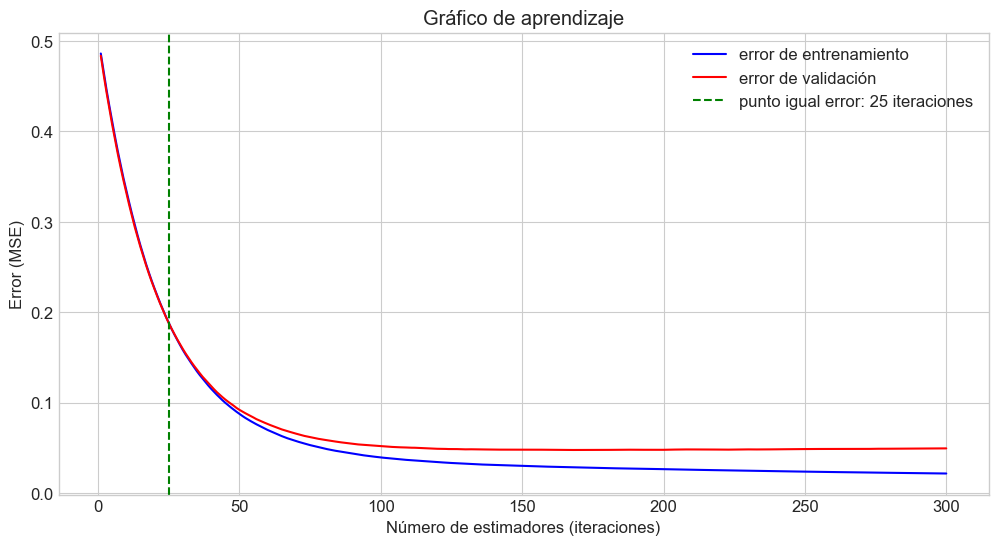

Las 10 siguientes iteraciones después de la iteración 154 no mejoran.


In [42]:
# Comprobación de mi modelo Gradient Boosting ajustados hiperparámetros
#'learning_rate', 0.024166621741563987), ('max_depth', 6), ('min_samples_leaf', 7), ('min_samples_split', 17), ('n_estimators', 257), ('subsample', 0.6008945150939967)
modelo_gb = GradientBoostingRegressor(random_state=42, learning_rate = 0.0241666, max_depth=6, min_samples_leaf=7, min_samples_split=17, n_estimators=100, subsample=0.6008945150939967)
graficar_aprendizaje(modelo_gb, X_train, y_train, X_val, y_val)

<a id="pipelines"></a>
<a href="#inicio-notebook"><p style="text-align:right;" href="#inicio-notebook">Volver al inicio</p></a> 
## 19. Pipelines: definición y prueba

<a id="resultados"></a>
<a href="#inicio-notebook"><p style="text-align:right;" href="#inicio-notebook">Volver al inicio</p></a> 
## 20. Resultados

Métricas finales del mejor modelo (Regresión Ridge):
RMSE: 222212.5301 €
MAPE: 18.7003 %


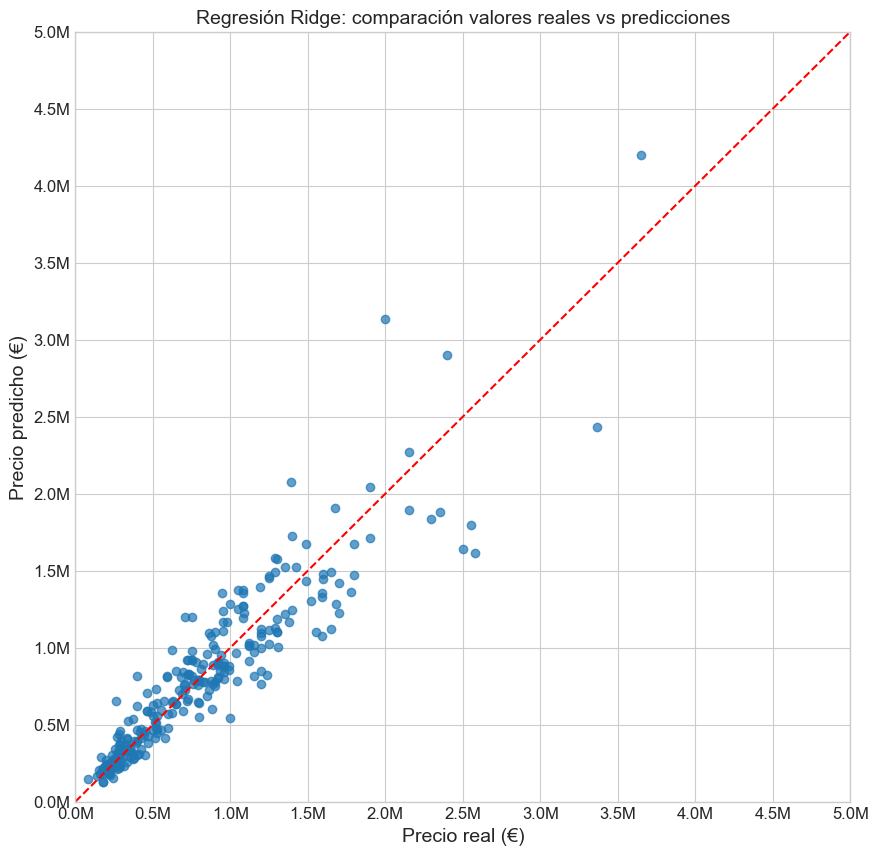


Resultados guardados:
{'RMSE val (original)': np.float64(222212.53006589142), 'MAPE val (original)': 18.70029159745696}


In [43]:
# para modelo Ridge, hiperparámetros mejores ()'alpha': 0.01, 'fit_intercept': True, 'max_iter': 1000, 'solver': 'lsqr'):
# Definir el mejor modelo (Ridge optimizado)
mejor_modelo = Ridge(alpha=0.01, fit_intercept=True, max_iter=1000, solver='lsqr')

# Entrenar el modelo con los datos de entrenamiento (suponiendo que ya tienes X_train y y_train)
mejor_modelo.fit(X_train, y_train)

# Realizar predicciones en la escala logarítmica
y_pred_log = mejor_modelo.predict(X_val)

# Transformar las predicciones y los valores reales de vuelta a la escala original
y_val_original = np.exp(y_val)  # Transformar los valores reales
y_pred_original = np.exp(y_pred_log)  # Transformar las predicciones

# Evaluar el rendimiento del modelo en la escala original
rmse_final = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
mape_final = mean_absolute_percentage_error(y_val_original, y_pred_original) * 100

# Imprimir las métricas finales
print("Métricas finales del mejor modelo (Regresión Ridge):")
print(f"RMSE: {rmse_final:.4f} €")
print(f"MAPE: {mape_final:.4f} %")

# Visualizar las predicciones vs los valores reales
plt.figure(figsize=(10, 10))  # Hacer el gráfico cuadrado

# Ajustar los límites de los ejes para que lleguen hasta 10M
plt.xlim(0, 5e6)
plt.ylim(0, 5e6)

# Visualizar
plt.scatter(y_val_original, y_pred_original, alpha=0.7)
plt.plot([0, 5e6], [0, 5e6], 'r--')  # Línea de referencia 45º

# Etiquetas
plt.xlabel('Precio real (€)', fontsize=14)
plt.ylabel('Precio predicho (€)', fontsize=14)
plt.title('Regresión Ridge: comparación valores reales vs predicciones', fontsize=14)

# Ajustar los ejes para que utilicen 0.5M, 1M, 1.5M, etc., hasta 10M
plt.xticks(np.arange(0, 5.5e6, step=0.5e6), 
           labels=[f'{x/1e6}M' for x in np.arange(0, 5.5e6, step=0.5e6)])

plt.yticks(np.arange(0, 5.5e6, step=0.5e6), 
           labels=[f'{y/1e6}M' for y in np.arange(0, 5.5e6, step=0.5e6)])
plt.show()

# Guardar resultados para análisis posterior
resultados = {
    'RMSE val (original)': rmse_final,
    'MAPE val (original)': mape_final
}

# Imprimir resultados
print("\nResultados guardados:")
print(resultados)


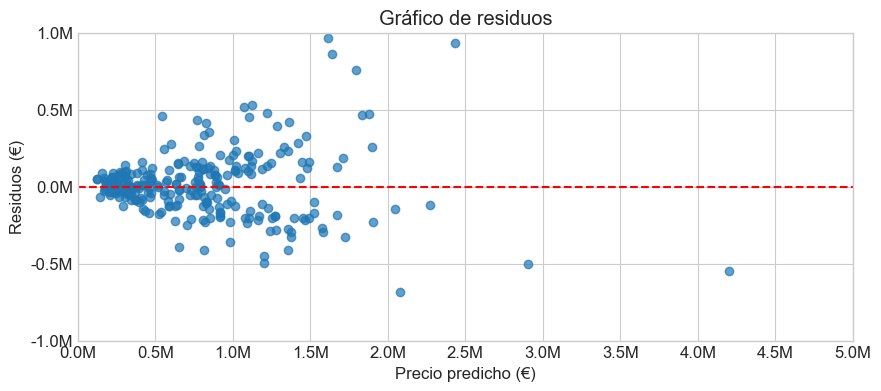

In [44]:
# Gráfico de los residuos de mi modelo.
# Realizamos las predicciones en la escala logarítmica
y_pred_log = mejor_modelo.predict(X_val)

# Transformamos las predicciones a la escala original (elevando a la exponencial)
y_val_original = np.exp(y_val)
y_pred_original = np.exp(y_pred_log)

# Calculamos los residuos
residuos = y_val_original - y_pred_original

# Visualizamos los residuos
plt.figure(figsize=(10, 4))

# Ajustar los límites de los ejes para que lleguen hasta 10M
plt.xlim(0, 5e6)
plt.ylim(-1e6, 1e6)

plt.scatter(y_pred_original, residuos, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')  # Línea horizontal en 0


plt.xlabel('Precio predicho (€)')
plt.ylabel('Residuos (€)')
plt.title('Gráfico de residuos')

# Ajustar los ejes para que utilicen 0.5M, 1M, 1.5M, etc., hasta 10M
plt.xticks(np.arange(0, 5.5e6, step=0.5e6), 
           labels=[f'{x/1e6}M' for x in np.arange(0, 5.5e6, step=0.5e6)])

plt.yticks(np.arange(-1e6, 1.01e6, step=0.5e6), 
           labels=[f'{y/1e6}M' for y in np.arange(-1e6, 1.01e6, step=0.5e6)])

plt.grid(True)
plt.show()


<a id="explicacion"></a>
<a href="#inicio-notebook"><p style="text-align:right;" href="#inicio-notebook">Volver al inicio</p></a> 
## 21. Explicación del modelo Machine Learning: LIME y SHAP